This notebook includes runs related to unmixing by using:

1. A very simple MLP, of various different sizes. These sizes are:
    - [32, 32],
    - [64, 64, 64]
    - [128, 128, 128, 128]
    - [256, 256, 256, 256]
    - [512, 512, 512, 512, 512]
    - [64, 1024, 1024, 1024, 1024, 64]
    - [64, 2048, 2048, 4096, 2048, 2048, 64]
2. Of varying learning rates fine tuned for the given model.
3. With dropout, optimized using AdamW.
4. A loss of simple MSE, with a small additional terms for sum of residuals.
5. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
6. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
7. Trained using a GPU.
8. Statistically normalized datasets.
9. Activations of LeakyReLU throughout the model, following BatchNorm, with the final activation layer of ReLU+L1norm.
10. Models initialized using Kaiming (He), tuned for LeakyReLUl leak constant of 0.2.


### Imports, data, model initialization, and various other setups

In [33]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [35]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.mlp import MLP
from src.dl.train import train_model

In [36]:
# Package imports
import torch
import torch.nn as nn

In [37]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [38]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 100
n_tb_epoch = 47

In [39]:
# Define model configs

models_list = [
    {'hidden_dim': [32, 32]},
    {'hidden_dim': [64, 64, 64]},
    {'hidden_dim': [128, 128, 128, 128]},
    {'hidden_dim': [256, 256, 256, 256]},
    {'hidden_dim': [512, 512, 512, 512, 512]},
    {'hidden_dim': [64, 1024, 1024, 1024, 1024, 64]},
    {'hidden_dim': [64, 2048, 2048, 4096, 2048, 2048, 64]}
]

lr_list = [1e-3, 1.25e-3, 2.5e-3, 5e-3, 7.5e-3, 1e-4, 1e-4]

dir_list = [
    'mlp_32',
    'mlp_64_3layer',
    'mlp_128_4layer',
    'mlp_256_4layer',
    'mlp_512_5layer',
    'mlp_64_1k_5layer',
    'mlp_64_2k_7layer'
]

name_list = [
        'MLP_32',
        'MLP_64_3layer',
        'MLP_128_4layer',
        'MLP_256_4layer',
        'MLP_512_5layer',
        'MLP_64_1k_5layer',
        'MLP_64_2k_7layer'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'mlp' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/100, Step 1/47, Train Loss: 0.259052
Epoch 1/100, Step 2/47, Train Loss: 0.194483
Epoch 1/100, Step 3/47, Train Loss: 0.233475
Epoch 1/100, Step 4/47, Train Loss: 0.196898
Epoch 1/100, Step 5/47, Train Loss: 0.178816
Epoch 1/100, Step 6/47, Train Loss: 0.164611
Epoch 1/100, Step 7/47, Train Loss: 0.177801
Epoch 1/100, Step 8/47, Train Loss: 0.163158
Epoch 1/100, Step 9/47, Train Loss: 0.161515
Epoch 1/100, Step 10/47, Train Loss: 0.194652
Epoch 1/100, Step 11/47, Train Loss: 0.147487
Epoch 1/100, Step 12/47, Train Loss: 0.210857
Epoch 1/100, Step 13/47, Train Loss: 0.173387
Epoch 1/100, Step 14/47, Train Loss: 0.166477
Epoch 1/100, Step 15/47, Train Loss: 0.153651
Epoch 1/100, Step 16/47, Train Loss: 0.186745
Epoch 1/100, Step 17/47, Train Loss: 0.150859
Epoch 1/100, Step 18/47, Train Loss: 0.146369
Epoch 1/100, Step 19/47, Train Loss: 0.152508
Epoch 1/100, Step 20/47, Train Loss: 0.108864
Epoch 1/100, Step 21/47, Train Loss: 0.165108
Epoch 1/100, Step 22/47, Train Loss: 0.1274

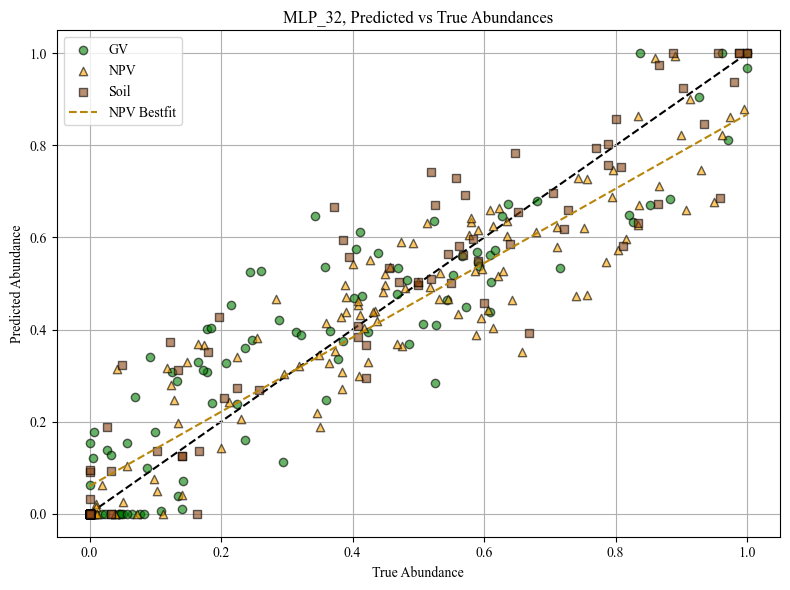

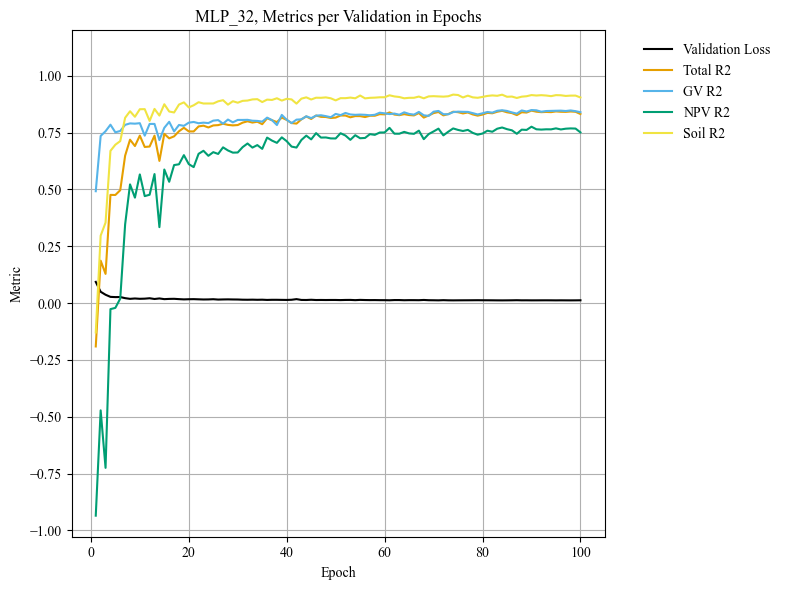

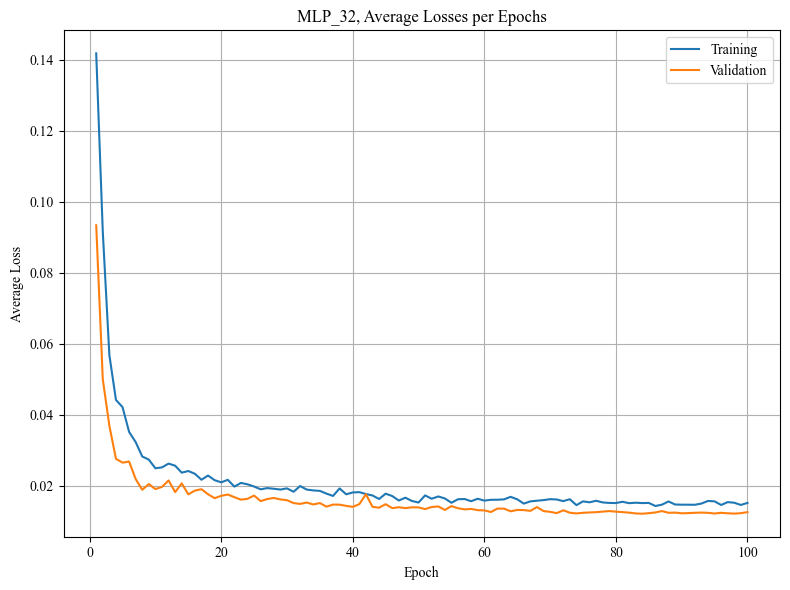

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.333280
Epoch 1/100, Step 2/47, Train Loss: 0.245232
Epoch 1/100, Step 3/47, Train Loss: 0.178685
Epoch 1/100, Step 4/47, Train Loss: 0.224148
Epoch 1/100, Step 5/47, Train Loss: 0.217863
Epoch 1/100, Step 6/47, Train Loss: 0.187534
Epoch 1/100, Step 7/47, Train Loss: 0.245297
Epoch 1/100, Step 8/47, Train Loss: 0.208988
Epoch 1/100, Step 9/47, Train Loss: 0.152025
Epoch 1/100, Step 10/47, Train Loss: 0.192229
Epoch 1/100, Step 11/47, Train Loss: 0.174803
Epoch 1/100, Step 12/47, Train Loss: 0.138225
Epoch 1/100, Step 13/47, Train Loss: 0.146548
Epoch 1/100, Step 14/47, Train Loss: 0.140355
Epoch 1/100, Step 15/47, Train Loss: 0.089475
Epoch 1/100, Step 16/47, Train Loss: 0.160378
Epoch 1/100, Step 17/47, Train Loss: 0.134852
Epoch 1/100, Step 18/47, Train Loss: 0.132453
Epoch 1/100, Step 19/47, Train Loss: 0.116166
Epoch 1/100, Step 20/47, Train Loss: 0.129048
Epoch 1/100, Step 21/47, Train Loss: 0.128677
Epoch 1/100, Step 22/47, T

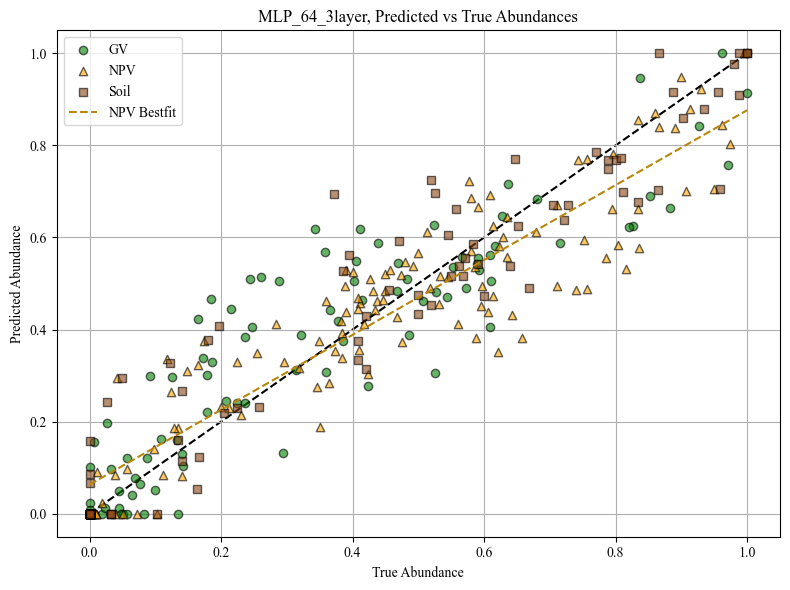

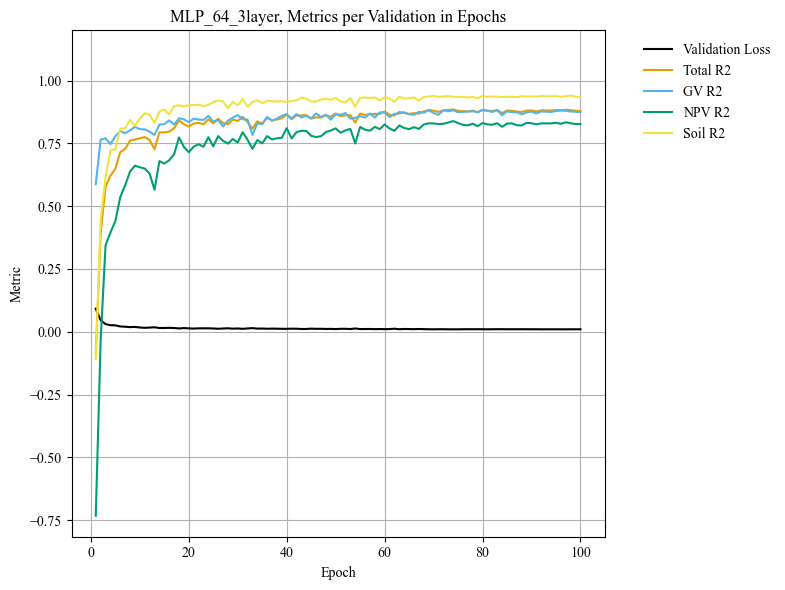

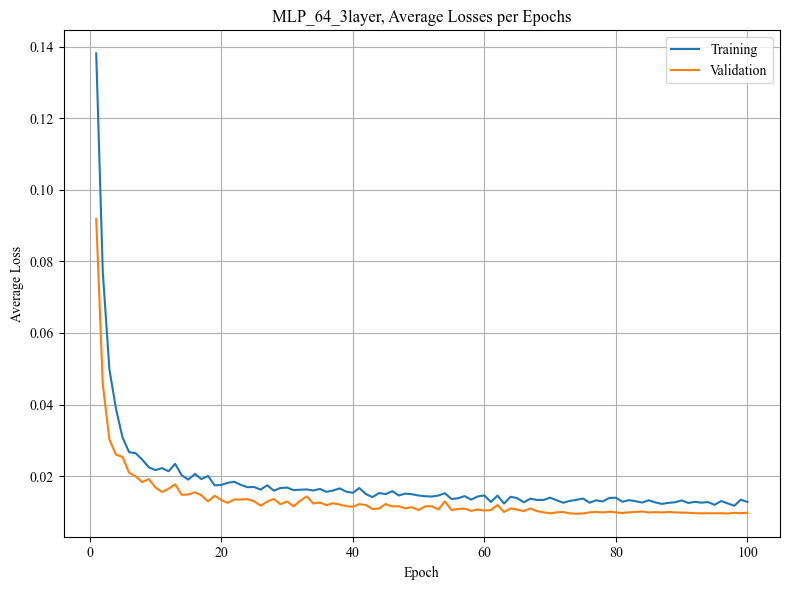

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.210905
Epoch 1/100, Step 2/47, Train Loss: 0.155014
Epoch 1/100, Step 3/47, Train Loss: 0.143988
Epoch 1/100, Step 4/47, Train Loss: 0.126101
Epoch 1/100, Step 5/47, Train Loss: 0.114149
Epoch 1/100, Step 6/47, Train Loss: 0.115737
Epoch 1/100, Step 7/47, Train Loss: 0.107123
Epoch 1/100, Step 8/47, Train Loss: 0.110303
Epoch 1/100, Step 9/47, Train Loss: 0.078553
Epoch 1/100, Step 10/47, Train Loss: 0.097481
Epoch 1/100, Step 11/47, Train Loss: 0.106272
Epoch 1/100, Step 12/47, Train Loss: 0.096273
Epoch 1/100, Step 13/47, Train Loss: 0.136263
Epoch 1/100, Step 14/47, Train Loss: 0.067075
Epoch 1/100, Step 15/47, Train Loss: 0.069803
Epoch 1/100, Step 16/47, Train Loss: 0.077825
Epoch 1/100, Step 17/47, Train Loss: 0.054544
Epoch 1/100, Step 18/47, Train Loss: 0.093575
Epoch 1/100, Step 19/47, Train Loss: 0.077902
Epoch 1/100, Step 20/47, Train Loss: 0.044675
Epoch 1/100, Step 21/47, Train Loss: 0.051538
Epoch 1/100, Step 22/47, T

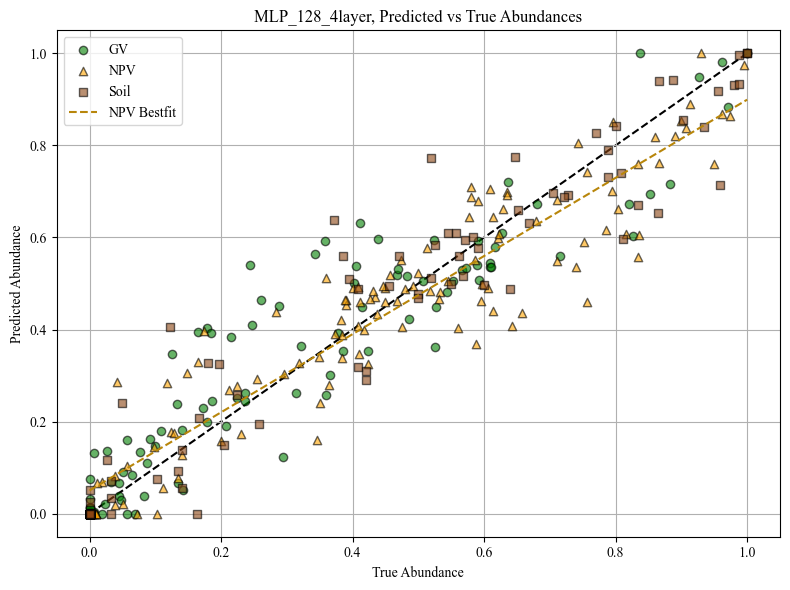

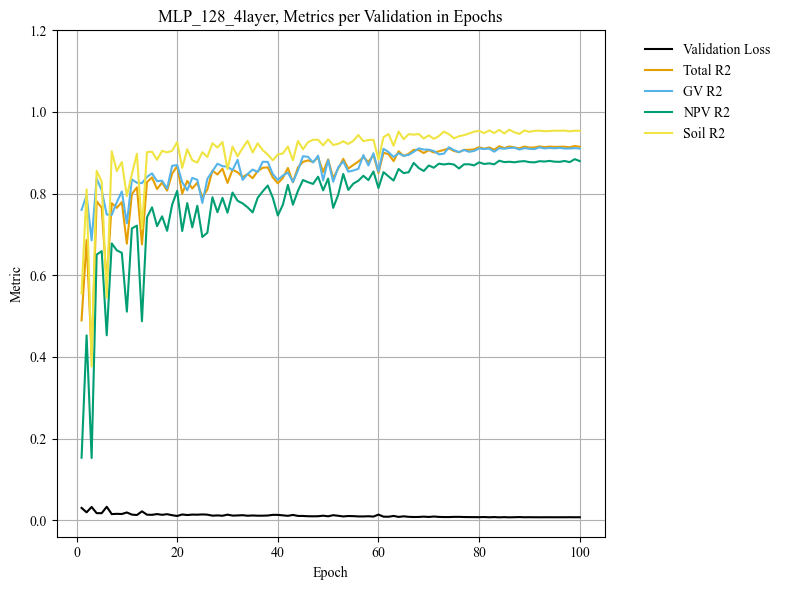

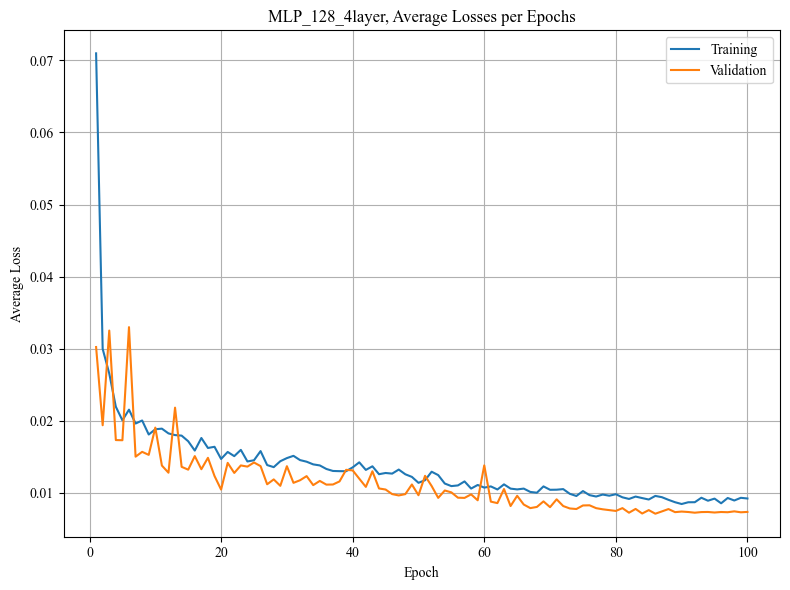

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.230882
Epoch 1/100, Step 2/47, Train Loss: 0.170711
Epoch 1/100, Step 3/47, Train Loss: 0.103728
Epoch 1/100, Step 4/47, Train Loss: 0.064504
Epoch 1/100, Step 5/47, Train Loss: 0.133059
Epoch 1/100, Step 6/47, Train Loss: 0.156625
Epoch 1/100, Step 7/47, Train Loss: 0.137711
Epoch 1/100, Step 8/47, Train Loss: 0.117414
Epoch 1/100, Step 9/47, Train Loss: 0.101426
Epoch 1/100, Step 10/47, Train Loss: 0.096903
Epoch 1/100, Step 11/47, Train Loss: 0.083962
Epoch 1/100, Step 12/47, Train Loss: 0.070084
Epoch 1/100, Step 13/47, Train Loss: 0.058858
Epoch 1/100, Step 14/47, Train Loss: 0.105868
Epoch 1/100, Step 15/47, Train Loss: 0.069157
Epoch 1/100, Step 16/47, Train Loss: 0.086919
Epoch 1/100, Step 17/47, Train Loss: 0.077326
Epoch 1/100, Step 18/47, Train Loss: 0.072008
Epoch 1/100, Step 19/47, Train Loss: 0.076385
Epoch 1/100, Step 20/47, Train Loss: 0.102239
Epoch 1/100, Step 21/47, Train Loss: 0.080159
Epoch 1/100, Step 22/47, T

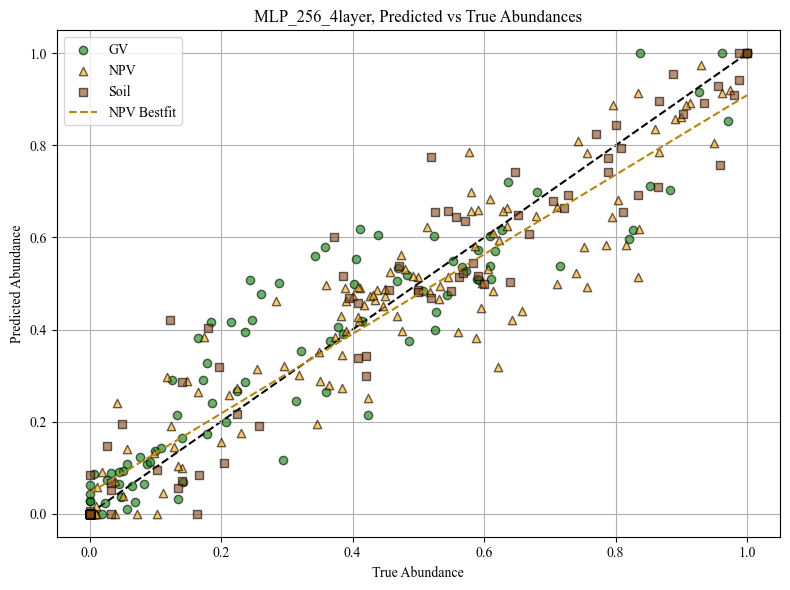

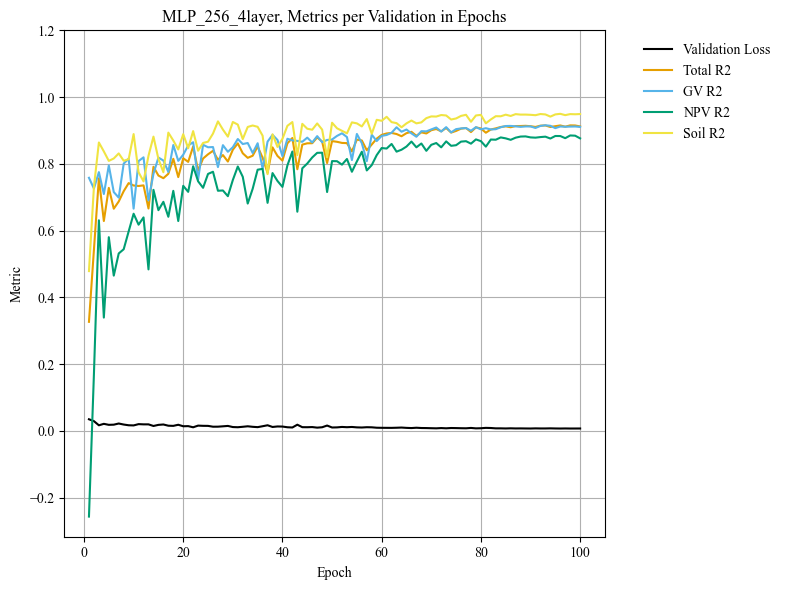

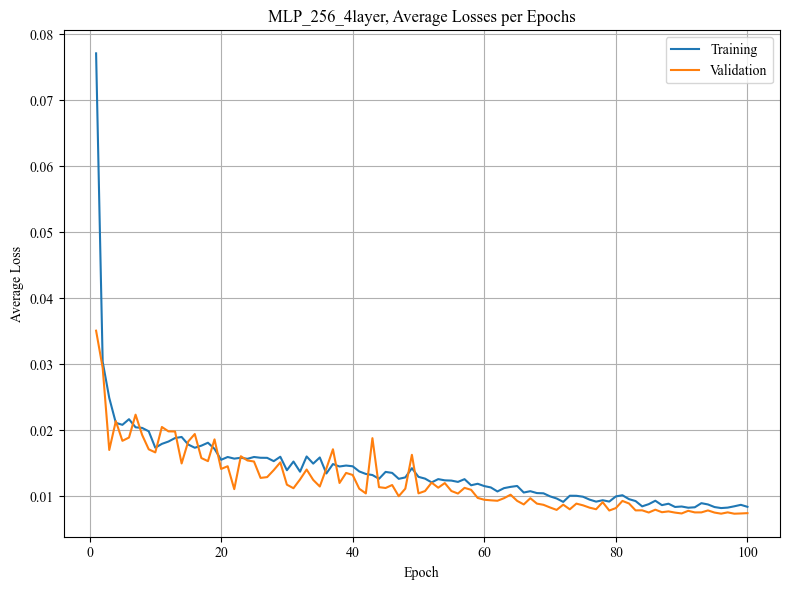

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.223184
Epoch 1/100, Step 2/47, Train Loss: 0.184401
Epoch 1/100, Step 3/47, Train Loss: 0.215478
Epoch 1/100, Step 4/47, Train Loss: 0.135255
Epoch 1/100, Step 5/47, Train Loss: 0.118609
Epoch 1/100, Step 6/47, Train Loss: 0.115896
Epoch 1/100, Step 7/47, Train Loss: 0.139256
Epoch 1/100, Step 8/47, Train Loss: 0.110909
Epoch 1/100, Step 9/47, Train Loss: 0.128140
Epoch 1/100, Step 10/47, Train Loss: 0.085589
Epoch 1/100, Step 11/47, Train Loss: 0.102386
Epoch 1/100, Step 12/47, Train Loss: 0.098671
Epoch 1/100, Step 13/47, Train Loss: 0.115737
Epoch 1/100, Step 14/47, Train Loss: 0.079938
Epoch 1/100, Step 15/47, Train Loss: 0.095866
Epoch 1/100, Step 16/47, Train Loss: 0.078299
Epoch 1/100, Step 17/47, Train Loss: 0.080761
Epoch 1/100, Step 18/47, Train Loss: 0.105990
Epoch 1/100, Step 19/47, Train Loss: 0.083480
Epoch 1/100, Step 20/47, Train Loss: 0.114895
Epoch 1/100, Step 21/47, Train Loss: 0.067837
Epoch 1/100, Step 22/47, T

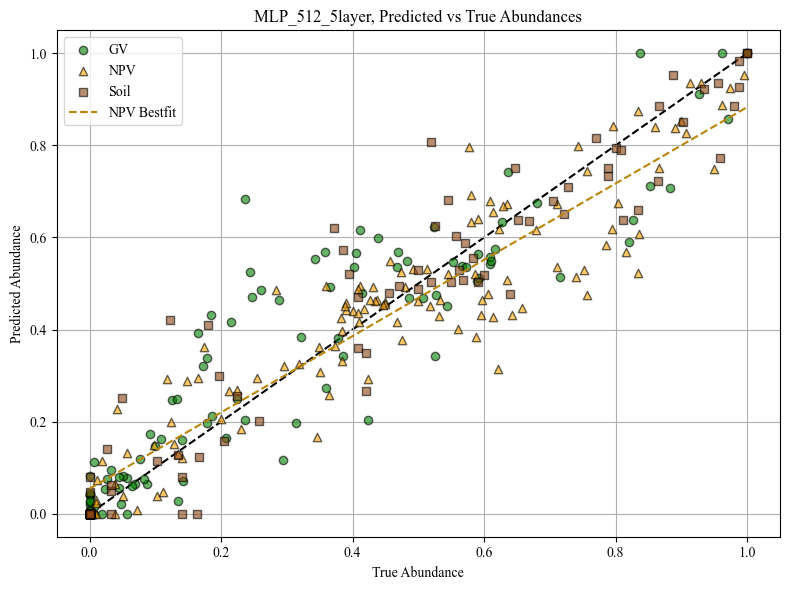

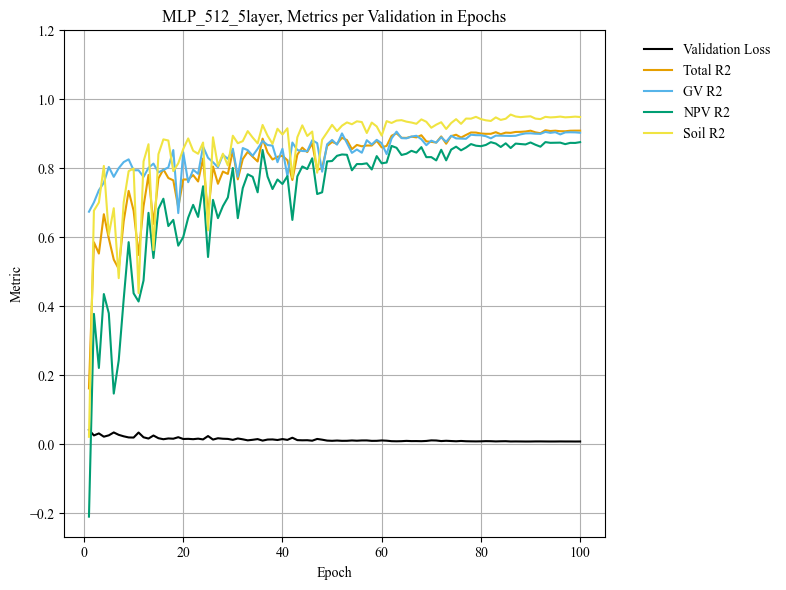

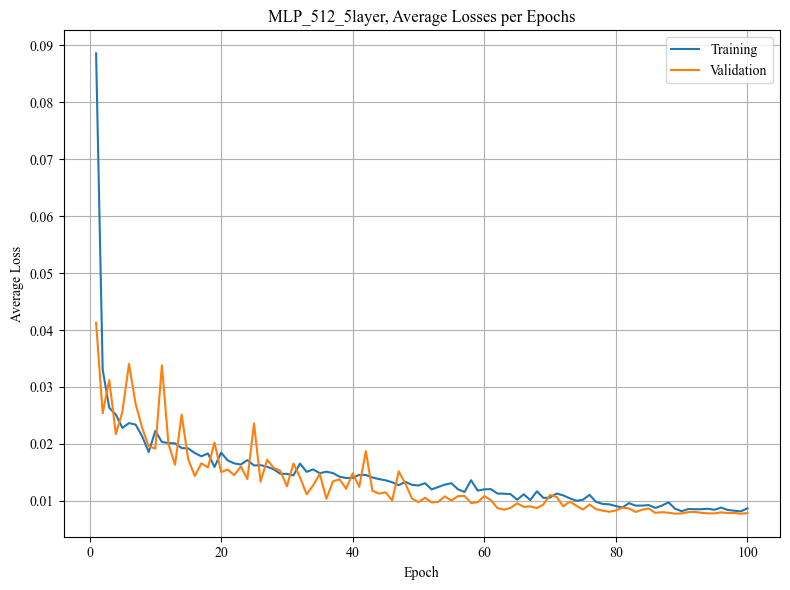

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.189815
Epoch 1/100, Step 2/47, Train Loss: 0.184517
Epoch 1/100, Step 3/47, Train Loss: 0.159310
Epoch 1/100, Step 4/47, Train Loss: 0.168679
Epoch 1/100, Step 5/47, Train Loss: 0.148132
Epoch 1/100, Step 6/47, Train Loss: 0.133702
Epoch 1/100, Step 7/47, Train Loss: 0.173570
Epoch 1/100, Step 8/47, Train Loss: 0.129308
Epoch 1/100, Step 9/47, Train Loss: 0.161091
Epoch 1/100, Step 10/47, Train Loss: 0.141022
Epoch 1/100, Step 11/47, Train Loss: 0.080613
Epoch 1/100, Step 12/47, Train Loss: 0.124621
Epoch 1/100, Step 13/47, Train Loss: 0.170105
Epoch 1/100, Step 14/47, Train Loss: 0.115614
Epoch 1/100, Step 15/47, Train Loss: 0.119193
Epoch 1/100, Step 16/47, Train Loss: 0.108013
Epoch 1/100, Step 17/47, Train Loss: 0.125547
Epoch 1/100, Step 18/47, Train Loss: 0.118588
Epoch 1/100, Step 19/47, Train Loss: 0.123785
Epoch 1/100, Step 20/47, Train Loss: 0.112312
Epoch 1/100, Step 21/47, Train Loss: 0.174050
Epoch 1/100, Step 22/47, T

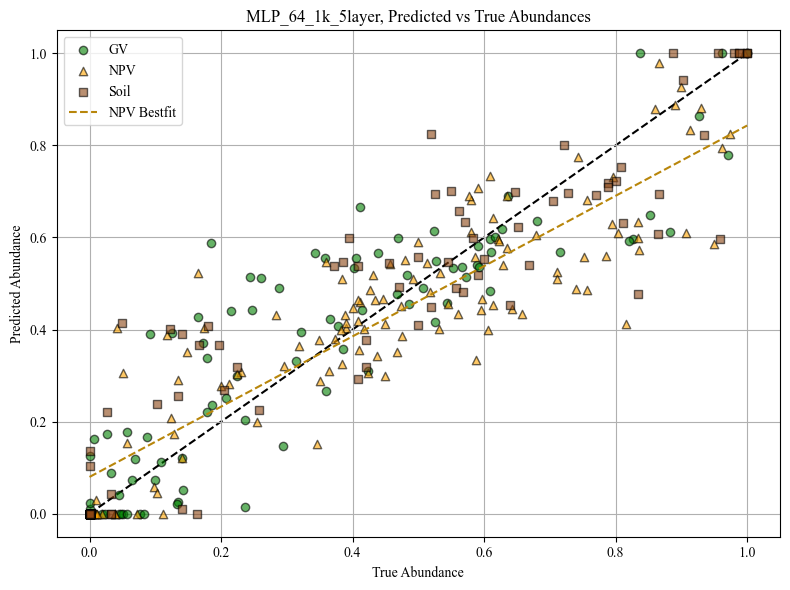

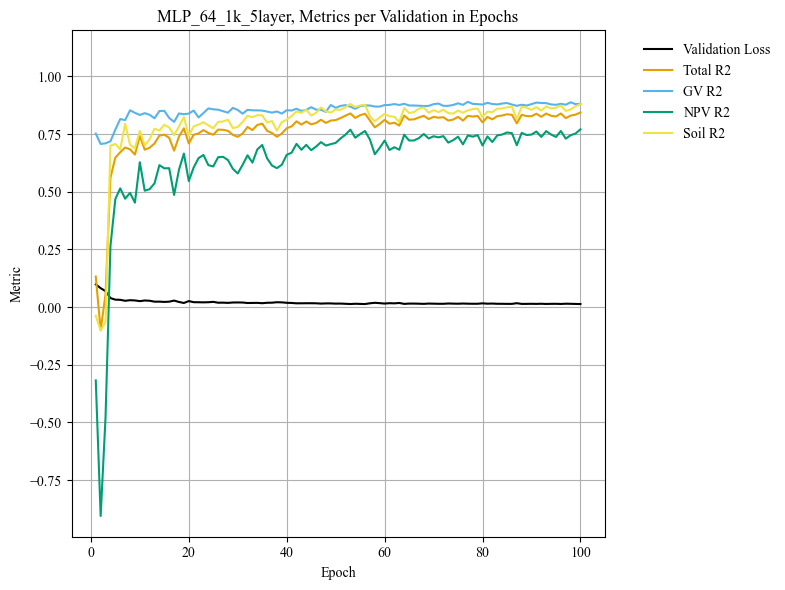

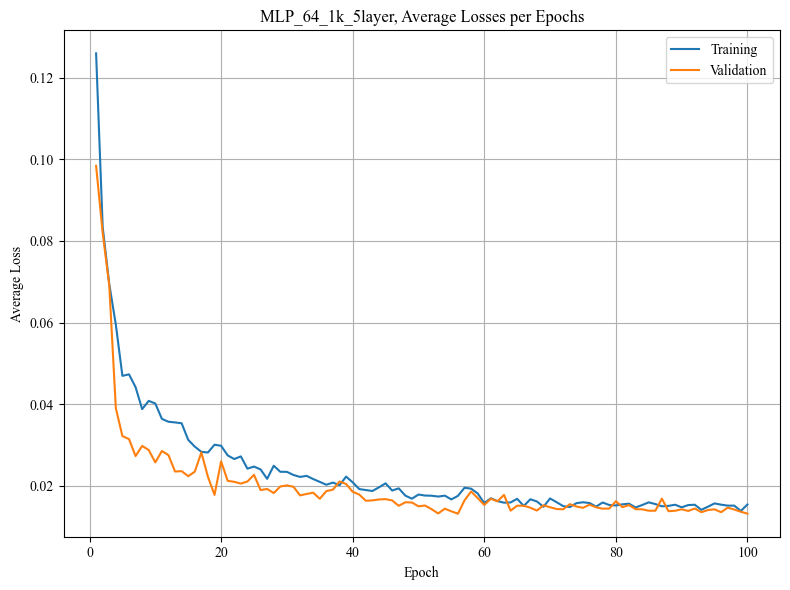

Testing complete
Epoch 1/100, Step 1/47, Train Loss: 0.285483
Epoch 1/100, Step 2/47, Train Loss: 0.132844
Epoch 1/100, Step 3/47, Train Loss: 0.123138
Epoch 1/100, Step 4/47, Train Loss: 0.096665
Epoch 1/100, Step 5/47, Train Loss: 0.156733
Epoch 1/100, Step 6/47, Train Loss: 0.133102
Epoch 1/100, Step 7/47, Train Loss: 0.102763
Epoch 1/100, Step 8/47, Train Loss: 0.091569
Epoch 1/100, Step 9/47, Train Loss: 0.080653
Epoch 1/100, Step 10/47, Train Loss: 0.082961
Epoch 1/100, Step 11/47, Train Loss: 0.096914
Epoch 1/100, Step 12/47, Train Loss: 0.110092
Epoch 1/100, Step 13/47, Train Loss: 0.076697
Epoch 1/100, Step 14/47, Train Loss: 0.098602
Epoch 1/100, Step 15/47, Train Loss: 0.090578
Epoch 1/100, Step 16/47, Train Loss: 0.064294
Epoch 1/100, Step 17/47, Train Loss: 0.075081
Epoch 1/100, Step 18/47, Train Loss: 0.096036
Epoch 1/100, Step 19/47, Train Loss: 0.095658
Epoch 1/100, Step 20/47, Train Loss: 0.084976
Epoch 1/100, Step 21/47, Train Loss: 0.089867
Epoch 1/100, Step 22/47, T

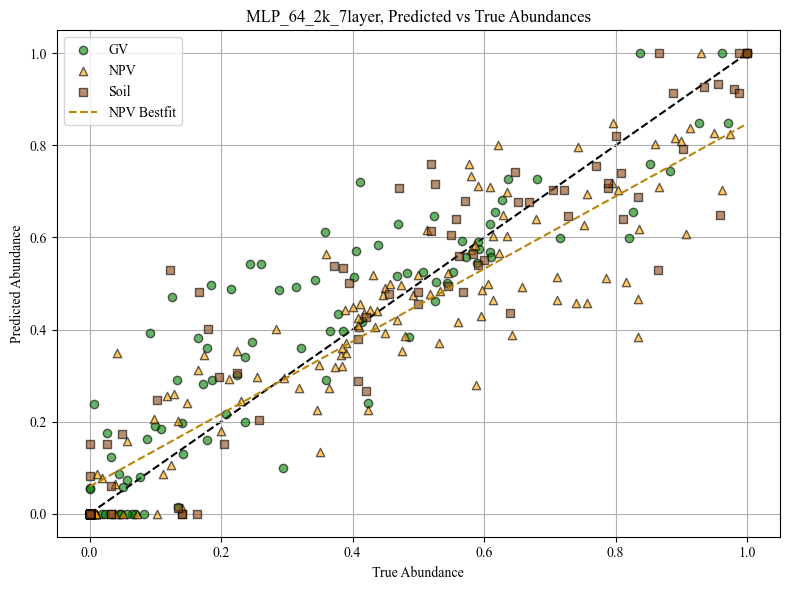

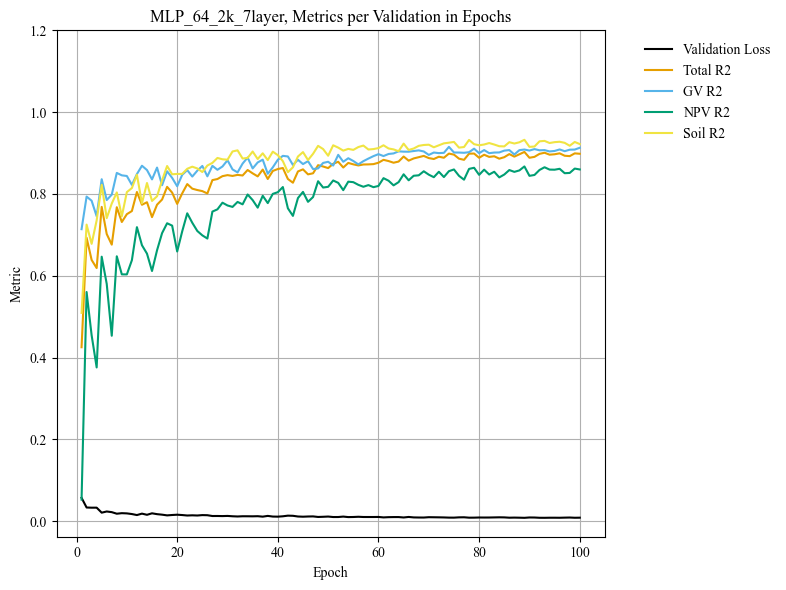

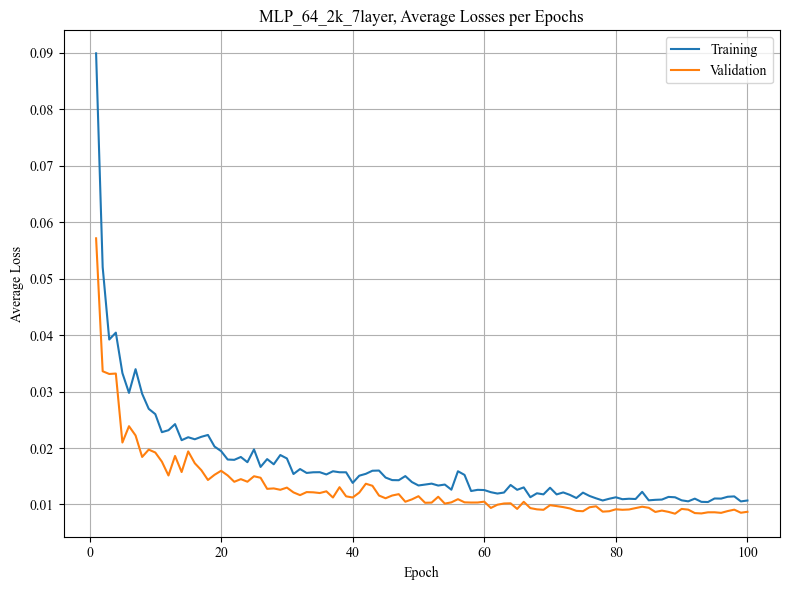

Testing complete


In [ ]:
mlp_dict = {}

for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'mlp' / dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1690], batch_size=32, SNV=True)
    model = MLP(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch*n_tb_epoch, eta_min=1e-6)
    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=str(save_dir),
        model_name=model_name,
        fine_tuning=False
    )

    mlp_dict[model_name] = model_dict

In [41]:
import pickle
with open('mlp_dict.pkl', 'wb') as fp:
    pickle.dump(mlp_dict, fp)

In [42]:
# Best model
print(mlp_dict['MLP_128_4layer']['metrics_total'])

[[6.13150000e+04 1.19552000e+05 8.25739559e-03 8.93491030e-01
  8.90243351e-01 8.43624949e-01 9.46604729e-01 5.96504696e-02
  6.10149242e-02 7.53164291e-02 4.26200666e-02]]


In [43]:
for i in mlp_dict.keys():
    print(f"For {i}, NPV R2: {mlp_dict[i]['metrics_total'][0][5]}, param#: {mlp_dict[i]['metrics_total'][0][0]}")

For MLP_32, NPV R2: 0.7825720310211182, param#: 3875.0
For MLP_64_3layer, NPV R2: 0.796235203742981, param#: 14083.0
For MLP_128_4layer, NPV R2: 0.8436249494552612, param#: 61315.0
For MLP_256_4layer, NPV R2: 0.8401904106140137, param#: 220931.0
For MLP_512_5layer, NPV R2: 0.8160070180892944, param#: 1098755.0
For MLP_64_1k_5layer, NPV R2: 0.6969442367553711, param#: 3294787.0
For MLP_64_2k_7layer, NPV R2: 0.7248606085777283, param#: 25470531.0
